# **Classification with scikit-learn**
Scikit-learn  is a free software machine learning library for the Python programming language. It features various classification, regression and clustering algorithms including support vector machines, random forests, gradient boosting, k-means and DBSCAN, and is designed to interoperate with the Python numerical and scientific libraries NumPy and SciPy.

##  **Topics covered**
* Feature extraction
* Linear Classifiers
* Non-Linear Classifiers
* Learning Curves
* Pipelines
* Hyper-parameter tuning

### **Install required packages**

In [1]:
!pip install numpy
!pip install scikit-learn
!pip install pandas
!pip install matplotlib


  Using cached https://files.pythonhosted.org/packages/3a/5f/47e578b3ae79e2624e205445ab77a1848acdaa2929a00eeef6b16eaaeb20/numpy-1.16.6-cp27-cp27mu-manylinux1_x86_64.whl
  Using cached https://files.pythonhosted.org/packages/31/9f/042db462417451e81035c3d43b722e88450c628a33dfda69777a801b0d40/scikit_learn-0.20.4-cp27-cp27mu-manylinux1_x86_64.whl
  Using cached https://files.pythonhosted.org/packages/24/40/11b12af7f322c1e20446c037c47344d89bab4922b8859419d82cf56d796d/scipy-1.2.3-cp27-cp27mu-manylinux1_x86_64.whl
  Using cached https://files.pythonhosted.org/packages/3a/5f/47e578b3ae79e2624e205445ab77a1848acdaa2929a00eeef6b16eaaeb20/numpy-1.16.6-cp27-cp27mu-manylinux1_x86_64.whl
  Using cached https://files.pythonhosted.org/packages/db/83/7d4008ffc2988066ff37f6a0bb6d7b60822367dcb36ba5e39aa7801fda54/pandas-0.24.2-cp27-cp27mu-manylinux1_x86_64.whl
  Using cached https://files.pythonhosted.org/packages/3a/5f/47e578b3ae79e2624e205445ab77a1848acdaa2929a00eeef6b16eaaeb20/numpy-1.16.6-cp27-cp27mu-m

#### **Download, unzip and load movies review data**

In [2]:
!wget http://www.cs.cornell.edu/people/pabo/movie-review-data/review_polarity.tar.gz
!tar xvzf review_polarity.tar.gz
from sklearn.datasets import load_files  
movies = load_files(r"txt_sentoken")  
X, y = movies.data, movies.target

--2020-05-03 22:23:57--  http://www.cs.cornell.edu/people/pabo/movie-review-data/review_polarity.tar.gz
Resolving www.cs.cornell.edu (www.cs.cornell.edu)... 132.236.207.20
Connecting to www.cs.cornell.edu (www.cs.cornell.edu)|132.236.207.20|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3127238 (3.0M) [application/x-gzip]
Saving to: ‘review_polarity.tar.gz’

review_polarity.tar 100%[===================>]   2.98M  1.52MB/s    in 2.0s    

2020-05-03 22:24:00 (1.52 MB/s) - ‘review_polarity.tar.gz’ saved [3127238/3127238]

txt_sentoken/neg/cv000_29416.txt
txt_sentoken/neg/cv001_19502.txt
txt_sentoken/neg/cv002_17424.txt
txt_sentoken/neg/cv003_12683.txt
txt_sentoken/neg/cv004_12641.txt
txt_sentoken/neg/cv005_29357.txt
txt_sentoken/neg/cv006_17022.txt
txt_sentoken/neg/cv007_4992.txt
txt_sentoken/neg/cv008_29326.txt
txt_sentoken/neg/cv009_29417.txt
txt_sentoken/neg/cv010_29063.txt
txt_sentoken/neg/cv011_13044.txt
txt_sentoken/neg/cv012_29411.txt
txt_sentoken/neg/cv0

In [5]:
X[0]

b"arnold schwarzenegger has been an icon for action enthusiasts , since the late 80's , but lately his films have been very sloppy and the one-liners are getting worse . \nit's hard seeing arnold as mr . freeze in batman and robin , especially when he says tons of ice jokes , but hey he got 15 million , what's it matter to him ? \nonce again arnold has signed to do another expensive blockbuster , that can't compare with the likes of the terminator series , true lies and even eraser . \nin this so called dark thriller , the devil ( gabriel byrne ) has come upon earth , to impregnate a woman ( robin tunney ) which happens every 1000 years , and basically destroy the world , but apparently god has chosen one man , and that one man is jericho cane ( arnold himself ) . \nwith the help of a trusty sidekick ( kevin pollack ) , they will stop at nothing to let the devil take over the world ! \nparts of this are actually so absurd , that they would fit right in with dogma . \nyes , the film is 

####  **Preprocess dataset**

In [3]:
import nltk
nltk.download('wordnet')
import re
from nltk.stem import WordNetLemmatizer

stemmer = WordNetLemmatizer()
docs = []
for sen in range(0, len(X)): 
    
    # Remove non-word characters such as punctuation, numbers etc
    document = re.sub(r'\W', ' ', str(X[sen]))

    # remove all single characters
    document = re.sub(r'\s+[a-zA-Z]\s+', ' ', document)

    # Remove single characters from the start
    document = re.sub(r'\^[a-zA-Z]\s+', ' ', document) 

    # Substituting multiple spaces with single space
    document = re.sub(r'\s+', ' ', document, flags=re.I)

    # Removing prefixed 'b'
    document = re.sub(r'^b\s+', '', document)

    # Converting to Lowercase
    document = document.lower()

    # Lemmatization
    document = document.split()

    document = [stemmer.lemmatize(word) for word in document]
    document = ' '.join(document)

    docs.append(document)

[nltk_data] Downloading package wordnet to /home/manolis/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
print(docs[0],y[0])

arnold schwarzenegger ha been an icon for action enthusiast since the late 80 but lately his film have been very sloppy and the one liner are getting worse nit hard seeing arnold a mr freeze in batman and robin especially when he say ton of ice joke but hey he got 15 million what it matter to him nonce again arnold ha signed to do another expensive blockbuster that can compare with the like of the terminator series true lie and even eraser nin this so called dark thriller the devil gabriel byrne ha come upon earth to impregnate woman robin tunney which happens every 1000 year and basically destroy the world but apparently god ha chosen one man and that one man is jericho cane arnold himself nwith the help of trusty sidekick kevin pollack they will stop at nothing to let the devil take over the world nparts of this are actually so absurd that they would fit right in with dogma nyes the film is that weak but it better than the other blockbuster right now sleepy hollow but it make the wor

#### **Split dataset into train (70%) & test (30%)**

In [0]:
from sklearn.model_selection import train_test_split  
X_train, X_test, y_train, y_test = train_test_split(docs, y, test_size=0.3, random_state=23828748)

## **Feature extraction (Tf*IDF n-gram features)**

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Exclude stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords

#Use unigram & bi-gram tf*idf features
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features = 5000,sublinear_tf=True, stop_words=stopwords.words('english'))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(vectorizer.get_feature_names())

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/manolis/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['000', '10', '100', '12', '13', '13th', '15', '17', '18', '1900', '1960s', '1970s', '1980', '1980s', '1981', '1984', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '19th', '20', '200', '2000', '2001', '25', '30', '40', '50', '60', '70', '80', '8mm', '90', '90 minute', '_the', 'abandon', 'abandoned', 'ability', 'able', 'aboard', 'absent', 'absolute', 'absolutely', 'absolutely nothing', 'absurd', 'abuse', 'academy', 'academy award', 'accent', 'accept', 'acceptable', 'accepts', 'accident', 'accidentally', 'acclaimed', 'accompanied', 'accomplish', 'accomplished', 'accomplishment', 'according', 'account', 'accurate', 'accused', 'ace', 'achieve', 'achieved', 'achievement', 'across', 'act', 'act like', 'acted', 'acting', 'action', 'action film', 'action flick', 'action movie', 'action scene', 'action sequence', 'activity', 'actor', 'actress', 'actual', 'actually', 'ad', 'adam', 'adam sandler', 'adaptation', 'adapted', 'add', 'added', 'adding', 'addition', 'address', 'adequat

In [7]:
X_test_tfidf[0,:]
#print(X_test_tfidf[0,:])

<1x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 158 stored elements in Compressed Sparse Row format>

## **Linear Classifiers**

#### **Baseline**

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

base = DummyClassifier(strategy='most_frequent')
base.fit(X_train_tfidf, y_train)
predictions = base.predict(X_train_tfidf)
score = accuracy_score(y_train, predictions)
print("train accuracy: %.2f%%" % (score*100))

predictions_test = base.predict(X_test_tfidf)
score = accuracy_score(y_test, predictions_test)
print("test accuracy: %.2f%%" % (score*100))
print()
print("test data confusion matrix")
y_true = pd.Series(y_test, name='True')
y_pred = pd.Series(predictions_test, name='Predicted')
pd.crosstab(y_true, y_pred)

train accuracy: 50.07%
test accuracy: 49.83%

test data confusion matrix


Predicted,0
True,
0,299
1,301


#### **Naive Bayes**

In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score

clf = MultinomialNB()
clf.fit(X_train_tfidf, y_train)
predictions = clf.predict(X_train_tfidf)
score = f1_score(y_train,predictions)
print("train f1-score: %.2f%%"%(score*100))

predictions_test = clf.predict(X_test_tfidf)
score = f1_score(y_test, predictions_test)
print("test f1-score: %.2f%%"%(score*100))
print()
print("test data confusion matrix")
y_true = pd.Series(y_test, name='True')
y_pred = pd.Series(predictions_test, name='Predicted')
pd.crosstab(y_true, y_pred)

train f1-score: 92.68%
test f1-score: 83.67%

test data confusion matrix


Predicted,0,1
True,,
0,258,41
1,55,246


#### **Logistic Regression**

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

clf = LogisticRegression(solver="liblinear")
clf.fit(X_train_tfidf, y_train)
predictions = clf.predict(X_train_tfidf)
score = f1_score(y_train,predictions)
print("train f1-score: %.2f%%"%(score*100))

predictions_test = clf.predict(X_test_tfidf)
score = f1_score(y_test, predictions_test)
print("test f1-score: %.2f%%"%(score*100))
print()
print("test data confusion matrix")
y_true = pd.Series(y_test, name='True')
y_pred = pd.Series(predictions_test, name='Predicted')
pd.crosstab(y_true, y_pred)

train f1-score: 97.05%
test f1-score: 84.91%

test data confusion matrix


Predicted,0,1
True,,
0,253,46
1,45,256


#### **SVM with linear kernel**

In [14]:
from sklearn import svm
from sklearn.metrics import f1_score


clf = svm.SVC(kernel='linear')
clf.fit(X_train_tfidf, y_train)
predictions = clf.predict(X_train_tfidf)
score = f1_score(y_train,predictions)
print("train f1-score: %.2f%%"%(score*100))

predictions_test = clf.predict(X_test_tfidf)
score = f1_score(y_test, predictions_test)
print("test f1-score: %.2f%%"%(score*100))
print()
print("test data confusion matrix")
y_true = pd.Series(y_test, name='True')
y_pred = pd.Series(predictions_test, name='Predicted')
pd.crosstab(y_true, y_pred)

train f1-score: 99.28%
test f1-score: 87.77%

test data confusion matrix


Predicted,0,1
True,,
0,265,34
1,39,262


## **Non-Linear Classifiers**

#### **KNN**

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train_tfidf, y_train)
predictions = clf.predict(X_train_tfidf)
score = f1_score(y_train,predictions)
print("train f1-score: %.2f%%"%(score*100))

predictions_test = clf.predict(X_test_tfidf)
score = f1_score(y_test, predictions_test)
print("test f1-score: %.2f%%"%(score*100))
print()
print("test data confusion matrix")
y_true = pd.Series(y_test, name='True')
y_pred = pd.Series(predictions_test, name='Predicted')
pd.crosstab(y_true, y_pred)

train f1-score: 83.33%
test f1-score: 75.27%

test data confusion matrix


Predicted,0,1
True,,
0,199,100
1,59,242


#### **KNN with dimensionality reduction**

In [16]:
# Reduce dimensionality using svd 5000 --> 100
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=4321)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train_svd, y_train)
predictions = clf.predict(X_train_svd)
score = f1_score(y_train,predictions)
print("train f1-score: %.2f%%"%(score*100))

predictions_test = clf.predict(X_test_svd)
score = f1_score(y_test, predictions_test)
print("test f1-score: %.2f%%"%(score*100))
print()
print("test data confusion matrix")
y_true = pd.Series(y_test, name='True')
y_pred = pd.Series(predictions_test, name='Predicted')
pd.crosstab(y_true, y_pred)

train f1-score: 85.29%
test f1-score: 73.77%

test data confusion matrix


Predicted,0,1
True,,
0,191,108
1,62,239


#### **MLP Classifier with 2 hidden layers**

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score

clf = MLPClassifier(solver='adam',hidden_layer_sizes=(100,100),early_stopping=True,random_state=123456)
clf.fit(X_train_tfidf, y_train)
predictions = clf.predict(X_train_tfidf)
score = f1_score(y_train,predictions)
print("train f1-score: %.2f%%"%(score*100))

predictions_test = clf.predict(X_test_tfidf)
score = f1_score(y_test, predictions_test)
print("test f1-score: %.2f%%"%(score*100))
print()
print("test data confusion matrix")
y_true = pd.Series(y_test, name='True')
y_pred = pd.Series(predictions_test, name='Predicted')
pd.crosstab(y_true, y_pred)

train f1-score: 97.71%
test f1-score: 86.18%

test data confusion matrix


Predicted,0,1
True,,
0,250,49
1,36,265


#### **Random Forest Classifier**

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

clf = RandomForestClassifier(n_estimators=5000, max_depth=4,random_state=284684)
clf.fit(X_train_tfidf, y_train)
predictions = clf.predict(X_train_tfidf)
score = f1_score(y_train,predictions)
print("train f1-score: %.2f%%"%(score*100))

predictions_test = clf.predict(X_test_tfidf)
score = f1_score(y_test, predictions_test)
print("test f1-score: %.2f%%"%(score*100))
print()
print("test data confusion matrix")
y_true = pd.Series(y_test, name='True')
y_pred = pd.Series(predictions_test, name='Predicted')
pd.crosstab(y_true, y_pred)

train f1-score: 94.80%
test f1-score: 83.66%

test data confusion matrix


Predicted,0,1
True,,
0,244,55
1,45,256


## **Learning Curves**

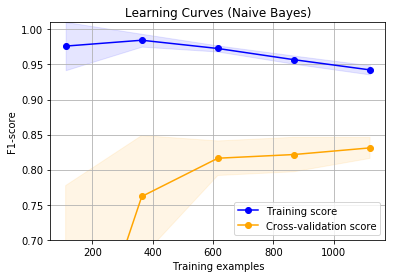

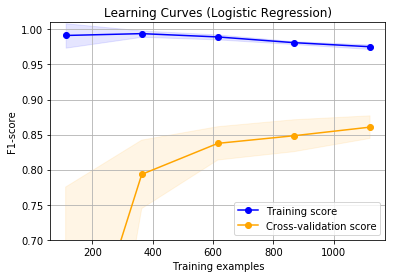

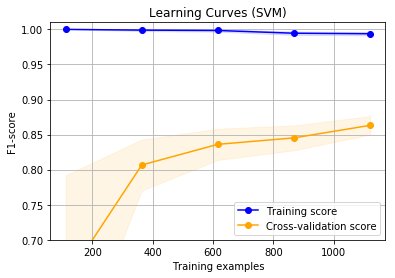

In [9]:
#Learning curves with cross-validtion
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5)):
   
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("F1-score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs,scoring='f1', train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="b")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="orange")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="b",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="orange",
             label="Cross-validation score")

    plt.legend(loc="lower right")
    return plt


X, y = X_train_tfidf,y_train

title = "Learning Curves (Naive Bayes)"
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
estimator = MultinomialNB()
plot_learning_curve(estimator, title, X, y, ylim=(0.7, 1.01), cv=cv, n_jobs=-1)
plt.show()

title = "Learning Curves (Logistic Regression)"
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
estimator = LogisticRegression()
plot_learning_curve(estimator, title, X, y, (0.7, 1.01), cv=cv, n_jobs=-1)
plt.show()

title = "Learning Curves (SVM)"
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
estimator = svm.SVC(kernel='linear')
plot_learning_curve(estimator, title, X, y, (0.7, 1.01), cv=cv, n_jobs=-1)
plt.show()

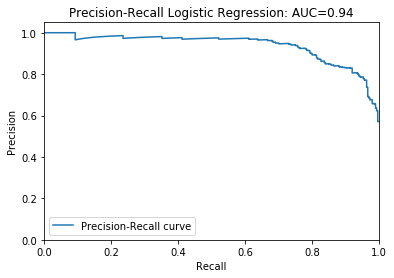

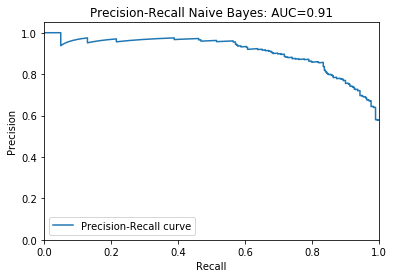

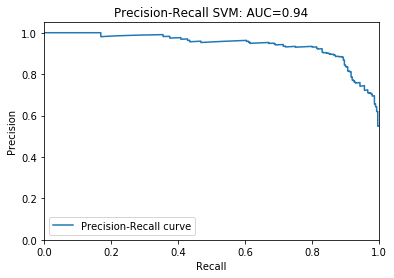

In [10]:
#Precision-Recall curves
import numpy as np
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.metrics import auc
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB


#disable warnings for large float numbers of estimated probabilities
np.seterr(all='ignore')
estimators = {'Logistic Regression':LogisticRegression(solver='liblinear'),
              'Naive Bayes':MultinomialNB(),
              'SVM':svm.SVC(kernel='linear',probability=True)}

for (name,estimator) in estimators.items():
    
    model =estimator
    model.fit(X_train_tfidf,y_train)
    pred = model.predict_proba(X_test_tfidf)
    precision, recall, thresholds = precision_recall_curve(y_test, pred[:,1])
    area = auc(recall, precision)

    plt.plot(recall, precision, label='Precision-Recall curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.0])
    plt.title('Precision-Recall %s: AUC=%0.2f' % (name,area))
    plt.legend(loc="lower left")
    plt.show()

## **Pipelines**

In [0]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer


lr_pipeline = Pipeline([
    ('tfidf_vectorizer', TfidfVectorizer()),
    ('lr', LogisticRegression())])

### **Hyper-parameter tuning via grid-search**

In [12]:
from sklearn.model_selection import GridSearchCV

grid_params = {
  'lr__solver': ['liblinear'],
  'lr__C': np.linspace(0.1, 1, 10),
  'lr__max_iter': [50, 100, 200],
  'tfidf_vectorizer__min_df': np.linspace(0.01, 0.1, 10),
  'tfidf_vectorizer__ngram_range': [(1,1),(1,2),(1,3)],  
  'tfidf_vectorizer__sublinear_tf': [True,False],
  
}

clf = GridSearchCV(lr_pipeline, grid_params,scoring='f1',cv=3, n_jobs=-1)
clf.fit(X_train, y_train)
print("Best Score: ", clf.best_score_)
print("Best Params: ", clf.best_params_)

Best Score:  0.8471673671787752
Best Params:  {'lr__C': 1.0, 'lr__max_iter': 50, 'lr__solver': 'liblinear', 'tfidf_vectorizer__min_df': 0.01, 'tfidf_vectorizer__ngram_range': (1, 1), 'tfidf_vectorizer__sublinear_tf': True}


### **Hyper-parameter tuning via random search**

In [13]:
from sklearn.model_selection import RandomizedSearchCV

clf2 = RandomizedSearchCV(lr_pipeline, grid_params,scoring='f1',cv=2,n_jobs=-1, n_iter=100)
clf2.fit(X_train, y_train)
print("Best Score: ", clf2.best_score_)
print("Best Params: ", clf2.best_params_)

Best Score:  0.8415697674418605
Best Params:  {'tfidf_vectorizer__sublinear_tf': True, 'tfidf_vectorizer__ngram_range': (1, 2), 'tfidf_vectorizer__min_df': 0.01, 'lr__solver': 'liblinear', 'lr__max_iter': 200, 'lr__C': 0.6}


## **References**

* https://scikit-learn.org/
* https://stackabuse.com/text-classification-with-python-and-scikit-learn/
* https://medium.com/@kocur4d/hyper-parameter-tuning-with-pipelines-5310aff069d6